# Toy simulation for private LQG vs. minimax private LQG

This notebook implements a **scalar toy version** of the setup in the attached draft:

- plant: \(x_{k+1} = A x_k + B u_k + w_k\), \(y_k = C x_k\),
- privatized measurement: \(\tilde y_k = y_k + v_k\),
- finite-horizon quadratic cost,
- ambiguity set consisting of either Gaussian privacy noise or Laplace privacy noise,
- lower bounds on the privacy-noise parameters from the DP condition,
- KL-ball relaxation and the outer \(\tau\)-search,
- comparison against standard finite-horizon LQG designed for the **nominal Gaussian** noise model.

Two ways to pick \(\tau\) are provided:

1. **`TAU_MODE = "closed_form"`**  
   Uses the scalar specialization of the paper's outer objective  
   \[
   \min_{\tau>0} \tau(\eta + W_\tau)
   \]
   and the fixed-\(\tau\) risk-sensitive recursions.

2. **`TAU_MODE = "empirical_worst_case"`**  
   Keeps the same fixed-\(\tau\) controller structure, but chooses \(\tau\) by minimizing the empirical worst-case mean cost over the extreme points of the ambiguity set. This is a practical diagnostic mode when the KL-bound objective is very conservative on a tiny toy example.

For the plots below:

- **mean** = Monte Carlo mean of \(J\),
- **95%** = Monte Carlo 95th percentile of \(J\),
- **worst** = maximum sampled \(J\) among the Monte Carlo runs at that parameter value.

Because this is a very small scalar example, the minimax controller is **not guaranteed** to dominate nominal LQG on every curve. The point of the notebook is to make the setup easy to tune and reproduce.


In [1]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.backends.backend_pgf
matplotlib.backends.backend_pgf.common_texification = matplotlib.backends.backend_pgf._tex_escape
from IPython.display import display
import tikzplotlib

plt.rcParams["figure.figsize"] = (7.0, 4.5)
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)


## 1. User-tunable configuration

The default system is a simple unstable scalar plant.  
Change `epsilon`, `delta`, `rho_sigma`, `rho_b`, `N`, and the Monte Carlo budget to explore other regimes.

For the scalar case,
\[
\|C\|_1 = |C|.
\]


In [2]:
# ---------------------------
# User-tunable configuration
# ---------------------------

SYSTEM = {
    "A": np.array([[1.15, 0.1], 
                   [0.0, 1.05]]),
    "B": np.array([[1.0], 
                   [0.5]]),
    "C": np.array([[1.0, 0.5]]),
    "Q": np.eye(2),
    "R": np.array([[0.30]]),
    "QN": np.eye(2),
    "Sigma_w": np.array([[0.05, 0.0], 
                         [0.0, 0.05]]),
    "x_ini": np.array([[1.0], 
                       [-1.0]]),
    "Sigma_ini": np.array([[0.20, 0.0], 
                           [0.0, 0.20]]),
}

PRIVACY = {
    "epsilon": math.log(2),
    "delta": 0.5,
    "gamma": 0.5,
    "rho_sigma": 1.2,
    "rho_b": 1.2,
}

SIM = {
    "N": 20,
    "n_mc": 10000,     
    "n_grid": 12,     
    "seed_gaussian": 123,
    "seed_laplace": 456,
}

TAU_MODE = "closed_form"          
TAU_GRID_CLOSED_FORM = np.logspace(-2, 4, 800)
TAU_GRID_EMPIRICAL = np.logspace(-2, 4, 120)
N_MC_TAU_EMPIRICAL = 400


## 2. Helper functions

The code below implements:

- the privacy lower bounds from Proposition 1,
- the KL radius from Theorem 1,
- the fixed-\(\tau\) controller from Proposition 2 in the **scalar** case,
- the outer \(\tau\)-search,
- vectorized Monte Carlo simulation,
- parameter sweeps and plotting helpers.


In [3]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def privacy_lower_bounds_vector(C, epsilon, delta, gamma):
    # Sensitivity depends on the norm. Using L2 norm for Gaussian and L1 for Laplace as typical.
    # C is 1x2, so its induced norm is just the vector norm.
    norm_2 = np.linalg.norm(C, ord=2)
    norm_1 = np.linalg.norm(C, ord=1) # Or max absolute column sum
    sigma2_lb = 2.0 * np.log(1.25 / delta) * (norm_2 ** 2) * (gamma ** 2) / (epsilon ** 2)
    b_lb = norm_1 * gamma / epsilon
    return float(sigma2_lb), float(b_lb)

def kl_radius_vector(sigma2_nom, sigma2_ub, b_lb, b_ub, L):
    # For a 1D measurement, the KL formulas remain scalar-like for the noise variances
    def gfun(x):
        return np.log(sigma2_nom / x) + x / sigma2_nom

    eta1 = float(gfun(sigma2_ub) - 1.0)
    eta2 = float(max(gfun(2.0 * b_lb ** 2), gfun(2.0 * b_ub ** 2)) - 2.0 + np.log(np.pi))
    eta = 0.5 * L * max(eta1, eta2)
    return float(eta), eta1, eta2

def synthesize_fixed_tau_minimax_vector(A, B, C, Q, R, QN, Sigma_w, x_ini, Sigma_ini, sigma2_nom, N, tau):
    n = A.shape[0]
    p = C.shape[0]
    m = B.shape[1]
    
    Sigma = [Sigma_ini.copy()]
    P = []
    Kest = []
    
    I = np.eye(n)
    R_inv = np.linalg.inv(R)
    Sigma_v_inv = np.array([[1.0 / sigma2_nom]])

    # Forward Riccati recursion
    for k in range(N):
        Pk = np.linalg.inv(Sigma[k]) + C.T @ Sigma_v_inv @ C - Q / tau
        # Check positive definiteness
        try:
            np.linalg.cholesky(Pk)
        except np.linalg.LinAlgError:
            return None
            
        P.append(Pk)
        Pk_inv = np.linalg.inv(Pk)
        Kk = A @ Pk_inv @ C.T @ Sigma_v_inv
        Kest.append(Kk)

        Sigma_next = Sigma_w + A @ Pk_inv @ A.T
        try:
            np.linalg.cholesky(Sigma_next)
        except np.linalg.LinAlgError:
            return None
        Sigma.append(Sigma_next)

    # Backward Riccati recursion
    Pi = [None] * (N + 1)
    Lk = [None] * (N + 1)
    Pi[N] = QN.copy()

    try:
        np.linalg.cholesky(np.linalg.inv(Pi[N]) - Sigma[N] / tau)
    except np.linalg.LinAlgError:
        return None

    for k in range(N - 1, -1, -1):
        Pi_kp1_inv = np.linalg.inv(Pi[k + 1])
        Lkp1 = Pi_kp1_inv + B @ R_inv @ B.T - Sigma_w / tau
        try:
            np.linalg.cholesky(Lkp1)
        except np.linalg.LinAlgError:
            return None
            
        Lk[k + 1] = Lkp1
        Lkp1_inv = np.linalg.inv(Lkp1)
        
        Pik = Q + A.T @ Lkp1_inv @ A
        try:
            np.linalg.cholesky(Pik)
        except np.linalg.LinAlgError:
            return None
        Pi[k] = Pik

        try:
            np.linalg.cholesky(np.linalg.inv(Pi[k + 1]) - Sigma_w / tau)
            np.linalg.cholesky(np.linalg.inv(Pi[k]) - Sigma[k] / tau)
        except np.linalg.LinAlgError:
            return None

    # Feedback gains
    F = []
    for k in range(N):
        denom = I - Sigma[k] @ Pi[k] / tau
        try:
            denom_inv = np.linalg.inv(denom)
        except np.linalg.LinAlgError:
            return None
            
        gain = R_inv @ B.T @ np.linalg.inv(Lk[k + 1]) @ A @ denom_inv
        F.append(gain)

    # Compute W_tau
    try:
        term1 = (x_ini.T @ np.linalg.inv(np.linalg.inv(Pi[0]) - Sigma_ini / tau) @ x_ini)[0, 0] / (2.0 * tau)
        _, logdet_Sigma_ini = np.linalg.slogdet(Sigma_ini)
        term2 = -0.5 * logdet_Sigma_ini
        term3 = 0.0
        term4 = 0.0

        for k in range(N):
            S_k = P[k] - C.T @ Sigma_v_inv @ C
            _, logdet_Sigma_kp1 = np.linalg.slogdet(Sigma[k + 1])
            _, logdet_S_k = np.linalg.slogdet(S_k)
            term3 += -0.5 * (logdet_Sigma_kp1 + logdet_S_k)

            Sk_inv = np.linalg.inv(S_k)
            inner_mat = I - (Kest[k] @ (np.array([[sigma2_nom]]) + C @ Sk_inv @ C.T) @ Kest[k].T @ 
                             np.linalg.inv(np.linalg.inv(Pi[k + 1]) - Sigma[k + 1] / tau)) / tau
            _, logdet_inner = np.linalg.slogdet(inner_mat)
            term4 += -0.5 * logdet_inner

        terminal_term = np.linalg.inv(Sigma[N]) - QN / tau
        _, logdet_term5 = np.linalg.slogdet(terminal_term)
        term5 = -0.5 * logdet_term5

        Wtau = float(term1 + term2 + term3 + term4 + term5)
    except np.linalg.LinAlgError:
        return None

    return {
        "kind": "minimax", "tau": float(tau), "Sigma": Sigma, "P": P, 
        "Kest": Kest, "Pi": Pi, "Lk": Lk, "F": F, "Wtau": Wtau
    }

def synthesize_nominal_lqg_vector(A, B, C, Q, R, QN, Sigma_w, Sigma_ini, sigma2_nom, N):
    n = A.shape[0]
    Sigma = [Sigma_ini.copy()]
    P = []
    Kest = []
    R_inv = np.linalg.inv(R)
    Sigma_v_inv = np.array([[1.0 / sigma2_nom]])

    for k in range(N):
        Pk = np.linalg.inv(Sigma[k]) + C.T @ Sigma_v_inv @ C
        P.append(Pk)
        Pk_inv = np.linalg.inv(Pk)
        Kk = A @ Pk_inv @ C.T @ Sigma_v_inv
        Kest.append(Kk)
        Sigma.append(Sigma_w + A @ Pk_inv @ A.T)

    Pi = [None] * (N + 1)
    Lk = [None] * (N + 1)
    Pi[N] = QN.copy()

    for k in range(N - 1, -1, -1):
        Lkp1 = np.linalg.inv(Pi[k + 1]) + B @ R_inv @ B.T
        Lk[k + 1] = Lkp1
        Pi[k] = Q + A.T @ np.linalg.inv(Lkp1) @ A

    F = []
    for k in range(N):
        F.append(R_inv @ B.T @ np.linalg.inv(Lk[k + 1]) @ A)

    return {
        "kind": "lqg", "Sigma": Sigma, "P": P, "Kest": Kest, 
        "Pi": Pi, "Lk": Lk, "F": F
    }

def synthesize_minimax_closed_form_vector(A, B, C, Q, R, QN, Sigma_w, x_ini, Sigma_ini, sigma2_nom, N, eta, tau_grid):
    objective = np.full_like(tau_grid, np.nan, dtype=float)
    best = None

    for i, tau in enumerate(tau_grid):
        ctrl = synthesize_fixed_tau_minimax_vector(
            A, B, C, Q, R, QN, Sigma_w, x_ini, Sigma_ini, sigma2_nom, N, float(tau)
        )
        if ctrl is None:
            continue
        value = float(tau) * (eta + ctrl["Wtau"])
        objective[i] = value
        if np.isfinite(value) and (best is None or value < best["objective"]):
            best = {"objective": float(value), "controller": ctrl}

    return best, objective

def simulate_controller_vector_vectorized(controller, A, B, C, Q, R, QN, Sigma_w, x_ini, Sigma_ini,
                                          noise_family, noise_param, N, n_mc=1000, seed=0):
    rng = np.random.default_rng(seed)
    n = A.shape[0]
    
    # x shape: (n_mc, n, 1)
    x = rng.multivariate_normal(x_ini.flatten(), Sigma_ini, size=n_mc)[..., np.newaxis]
    xhat = np.tile(x_ini, (n_mc, 1, 1))
    cost = np.zeros(n_mc)

    for k in range(N):
        u = -controller["F"][k] @ xhat  # (n_mc, 1, 1)
        
        # cost = x^T Q x + u^T R u
        x_cost = np.squeeze(np.transpose(x, (0, 2, 1)) @ Q @ x)
        u_cost = np.squeeze(np.transpose(u, (0, 2, 1)) @ R @ u)
        cost += 0.5 * (x_cost + u_cost)

        if noise_family == "gaussian":
            v = rng.normal(0.0, math.sqrt(noise_param), size=(n_mc, 1, 1))
        elif noise_family == "laplace":
            v = rng.laplace(0.0, noise_param, size=(n_mc, 1, 1))

        ytilde = C @ x + v

        if controller["kind"] == "minimax":
            tau = controller["tau"]
            xhat = (
                A @ xhat 
                + B @ u 
                + controller["Kest"][k] @ (ytilde - C @ xhat)
                + A @ np.linalg.inv(controller["P"][k]) @ (Q / tau) @ xhat
            )
        else:
            xhat = A @ xhat + B @ u + controller["Kest"][k] @ (ytilde - C @ xhat)

        w = rng.multivariate_normal(np.zeros(n), Sigma_w, size=n_mc)[..., np.newaxis]
        x = A @ x + B @ u + w

    x_term_cost = np.squeeze(np.transpose(x, (0, 2, 1)) @ QN @ x)
    cost += 0.5 * x_term_cost
    return cost

def tune_tau_empirical_worst_case_vector(A, B, C, Q, R, QN, Sigma_w, x_ini, Sigma_ini, sigma2_nom, N,
                                         noise_grid, tau_grid, n_mc_inner=400, seed=123):
    objective = np.full_like(tau_grid, np.nan, dtype=float)
    best = None
    for i, tau in enumerate(tau_grid):
        ctrl = synthesize_fixed_tau_minimax_vector(
            A, B, C, Q, R, QN, Sigma_w, x_ini, Sigma_ini, sigma2_nom, N, float(tau)
        )
        if ctrl is None:
            continue
        wc = -np.inf
        for fam, param in noise_grid:
            costs = simulate_controller_vector_vectorized(
                controller=ctrl, A=A, B=B, C=C, Q=Q, R=R, QN=QN, Sigma_w=Sigma_w,
                x_ini=x_ini, Sigma_ini=Sigma_ini, noise_family=fam, noise_param=float(param),
                N=N, n_mc=n_mc_inner, seed=seed
            )
            wc = max(wc, float(np.mean(costs)))
        objective[i] = wc
        if best is None or wc < best["objective"]:
            best = {"objective": float(wc), "controller": ctrl}
    return best, objective

# The evaluation and plotting functions remain the same logic, 
# just be sure to call `simulate_controller_vector_vectorized` inside `evaluate_grid`.
def evaluate_grid(controller, A, B, C, Q, R, QN, Sigma_w, x_ini, Sigma_ini,
                  noise_family, param_grid, N, n_mc=1000, seed=0):
    rows = []
    for i, param in enumerate(param_grid):
        costs = simulate_controller_vector_vectorized(
            controller=controller, A=A, B=B, C=C, Q=Q, R=R, QN=QN, Sigma_w=Sigma_w,
            x_ini=x_ini, Sigma_ini=Sigma_ini, noise_family=noise_family, noise_param=float(param),
            N=N, n_mc=n_mc, seed=seed + i
        )
        rows.append({
            "param": float(param),
            "mean": float(np.mean(costs)),
            "q95": float(np.quantile(costs, 0.95)),
            "worst": float(np.max(costs)),
        })
    return pd.DataFrame(rows)


def summarize_family(df_mm, df_lqg, family_name):
    rows = []
    for metric in ["mean", "q95", "worst"]:
        rows.append({
            "family": family_name,
            "metric": metric,
            "worst_over_grid_minimax": float(df_mm[metric].max()),
            "worst_over_grid_lqg": float(df_lqg[metric].max()),
            "best_over_grid_minimax": float(df_mm[metric].min()),
            "best_over_grid_lqg": float(df_lqg[metric].min()),
        })
    return pd.DataFrame(rows)


def plot_metric(df_mm, df_lqg, metric, xlabel, title_prefix):
    plt.figure()
    plt.plot(df_mm["param"], df_mm[metric], marker="o", label="Minimax private LQG")
    plt.plot(df_lqg["param"], df_lqg[metric], marker="o", label="Nominal Gaussian LQG")
    plt.xlabel(xlabel)
    plt.ylabel(metric)
    plt.title(f"{title_prefix}: {metric}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_all_metrics_two_by_one(gauss_mm, gauss_lqg, lap_mm, lap_lqg):
    fig, axes = plt.subplots(2, 1, figsize=(10, 9), constrained_layout=True)
    metric_style = [
        ("mean", "C0"),
        ("q95", "C1"),
        ("worst", "C2"),
    ]

    panel_spec = [
        (axes[0], gauss_mm, gauss_lqg, "Gaussian Truth", "true Gaussian variance"),
        (axes[1], lap_mm, lap_lqg, "Laplace Truth", "true Laplace scale"),
    ]

    for ax, df_mm, df_lqg, title, xlabel in panel_spec:
        for metric, color in metric_style:
            ax.plot(
                df_mm["param"],
                df_mm[metric],
                marker="o",
                linestyle="-",
                color=color,
                label=f"Minimax {metric}",
            )
            ax.plot(
                df_lqg["param"],
                df_lqg[metric],
                marker="x",
                linestyle="--",
                color=color,
                label=f"LQG {metric}",
            )

        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("mean ~~ q95 ~~ worst")
        ax.grid(True, alpha=0.3)
        ax.set_yscale("log")
        ax.legend(ncol=2)
    tikzplotlib.save("result.tex")
    plt.show()


## 3. Compute privacy bounds, build the ambiguity set, and synthesize the controllers

In [4]:

sigma2_lb, b_lb = privacy_lower_bounds_vector(
    C=SYSTEM["C"],
    epsilon=PRIVACY["epsilon"],
    delta=PRIVACY["delta"],
    gamma=PRIVACY["gamma"],
)

sigma2_ub = PRIVACY["rho_sigma"] * sigma2_lb
b_ub = PRIVACY["rho_b"] * b_lb

eta, eta1, eta2 = kl_radius_vector(
    sigma2_nom=sigma2_lb,
    sigma2_ub=sigma2_ub,
    b_lb=b_lb,
    b_ub=b_ub,
    L=SIM["N"] + 1,  # scalar output => p = 1, so L = N + 1
)

print("Privacy bounds from Proposition 1")
print(f"  sigma^2 lower bound : {sigma2_lb:.6f}")
print(f"  b lower bound       : {b_lb:.6f}")
print()
print("Upper bounds chosen for the toy ambiguity set")
print(f"  sigma^2 upper bound : {sigma2_ub:.6f}")
print(f"  b upper bound       : {b_ub:.6f}")
print()
print("KL-ball quantities from Theorem 1")
print(f"  eta1 = {eta1:.6f}")
print(f"  eta2 = {eta2:.6f}")
print(f"  eta  = {eta:.6f}")

nominal_lqg = synthesize_nominal_lqg_vector(
    A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
    Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
    Sigma_w=SYSTEM["Sigma_w"], Sigma_ini=SYSTEM["Sigma_ini"],
    sigma2_nom=sigma2_lb, N=SIM["N"],
)

if TAU_MODE == "closed_form":
    tau_solution, tau_objective_curve = synthesize_minimax_closed_form_vector(
        A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
        Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
        Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
        sigma2_nom=sigma2_lb, N=SIM["N"], eta=eta,
        tau_grid=TAU_GRID_CLOSED_FORM,
    )
    tau_xlabel = "tau"
    tau_ylabel = "tau * (eta + W_tau)"
else:
    extreme_noise_grid = [
        ("gaussian", sigma2_lb),
        ("gaussian", sigma2_ub),
        ("laplace", b_lb),
        ("laplace", b_ub),
    ]
    tau_solution, tau_objective_curve = tune_tau_empirical_worst_case_vector(
        A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
        Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
        Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
        sigma2_nom=sigma2_lb, N=SIM["N"], noise_grid=extreme_noise_grid,
        tau_grid=TAU_GRID_EMPIRICAL, n_mc_inner=N_MC_TAU_EMPIRICAL, seed=SIM["seed_gaussian"],
    )
    tau_xlabel = "tau"
    tau_ylabel = "empirical worst-case mean cost"

if tau_solution is None:
    raise RuntimeError("No feasible tau was found on the grid. Try enlarging the tau grid or relaxing the toy setup.")

minimax_ctrl = tau_solution["controller"]

print()
print(f"Selected tau ({TAU_MODE}) = {minimax_ctrl['tau']:.6f}")
if TAU_MODE == "closed_form":
    print(f"Best outer objective      = {tau_solution['objective']:.6f}")
else:
    print(f"Best empirical worst-case = {tau_solution['objective']:.6f}")


Privacy bounds from Proposition 1
  sigma^2 lower bound : 1.191962
  b lower bound       : 0.721348

Upper bounds chosen for the toy ambiguity set
  sigma^2 upper bound : 1.430354
  b upper bound       : 0.865617

KL-ball quantities from Theorem 1
  eta1 = 0.017678
  eta2 = 0.173052
  eta  = 1.817042

Selected tau (closed_form) = 27.977475
Best outer objective      = 119.431548


## 4. Optional diagnostic: outer objective as a function of \(\tau\)

This plot is often useful to check that the one-dimensional outer optimization is numerically well behaved on the chosen toy example.


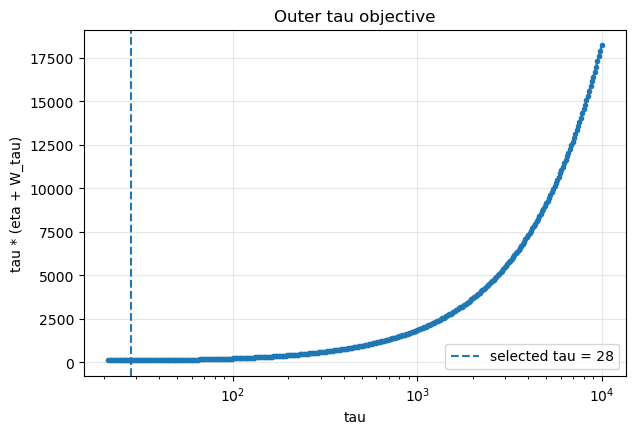

In [5]:
import webcolors

# Recreate the deleted dictionary so tikzplotlib doesn't crash
if not hasattr(webcolors, "CSS3_HEX_TO_NAMES"):
    webcolors.CSS3_HEX_TO_NAMES = {
        webcolors.name_to_hex(name): name 
        for name in webcolors.names("css3")
    }

import matplotlib.lines
import matplotlib.legend

# 1. The Line Dash Patch (Corrected!)
matplotlib.lines.Line2D._us_dashSeq = property(lambda self: self._dash_pattern[1])
matplotlib.lines.Line2D._us_dashOffset = property(lambda self: self._dash_pattern[0])

# 2. The Legend Patch (To prevent the inevitable crash on plt.legend())
matplotlib.legend.Legend._ncol = property(lambda self: self._ncols)

if not hasattr(np, "float_"):
    np.float_ = np.float64

plt.figure()
if TAU_MODE == "closed_form":
    tau_grid_used = TAU_GRID_CLOSED_FORM
else:
    tau_grid_used = TAU_GRID_EMPIRICAL

mask = np.isfinite(tau_objective_curve)
plt.semilogx(tau_grid_used[mask], tau_objective_curve[mask], marker=".")
plt.axvline(minimax_ctrl["tau"], linestyle="--", label=f"selected tau = {minimax_ctrl['tau']:.3g}")
plt.xlabel(tau_xlabel)
plt.ylabel(tau_ylabel)
plt.title("Outer tau objective")
plt.grid(True, alpha=0.3)
plt.legend()
tikzplotlib.save("tau.tex")
plt.show()


## 5. Sweep the true privacy-noise parameter in each family

In [6]:

gaussian_grid = np.linspace(sigma2_lb, sigma2_ub, SIM["n_grid"])
laplace_grid = np.linspace(b_lb, b_ub, SIM["n_grid"])

gaussian_minimax = evaluate_grid(
    controller=minimax_ctrl,
    A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
    Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
    Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
    noise_family="gaussian", param_grid=gaussian_grid,
    N=SIM["N"], n_mc=SIM["n_mc"], seed=SIM["seed_gaussian"],
)

gaussian_lqg = evaluate_grid(
    controller=nominal_lqg,
    A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
    Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
    Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
    noise_family="gaussian", param_grid=gaussian_grid,
    N=SIM["N"], n_mc=SIM["n_mc"], seed=SIM["seed_gaussian"],
)

laplace_minimax = evaluate_grid(
    controller=minimax_ctrl,
    A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
    Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
    Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
    noise_family="laplace", param_grid=laplace_grid,
    N=SIM["N"], n_mc=SIM["n_mc"], seed=SIM["seed_laplace"],
)

laplace_lqg = evaluate_grid(
    controller=nominal_lqg,
    A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
    Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
    Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
    noise_family="laplace", param_grid=laplace_grid,
    N=SIM["N"], n_mc=SIM["n_mc"], seed=SIM["seed_laplace"],
)

summary = pd.concat(
    [
        summarize_family(gaussian_minimax, gaussian_lqg, "Gaussian truth"),
        summarize_family(laplace_minimax, laplace_lqg, "Laplace truth"),
    ],
    ignore_index=True,
)

display(summary)


,family,metric,worst_over_grid_minimax,worst_over_grid_lqg,best_over_grid_minimax,best_over_grid_lqg
0,Gaussian truth,mean,51.0271,43.7860,49.7703,42.4742
1,Gaussian truth,q95,92.5799,100.5261,90.1250,96.3988
2,Gaussian truth,worst,254.9704,304.6987,200.9149,231.5248
3,Laplace truth,mean,51.2745,44.0259,49.4250,42.3133
4,Laplace truth,q95,92.7662,99.4055,89.8280,97.1536
5,Laplace truth,worst,259.0556,310.8468,201.8407,236.1452


## 6. Gaussian truth: metrics vs. true Gaussian variance \(\sigma_{\mathrm{true}}^2\)

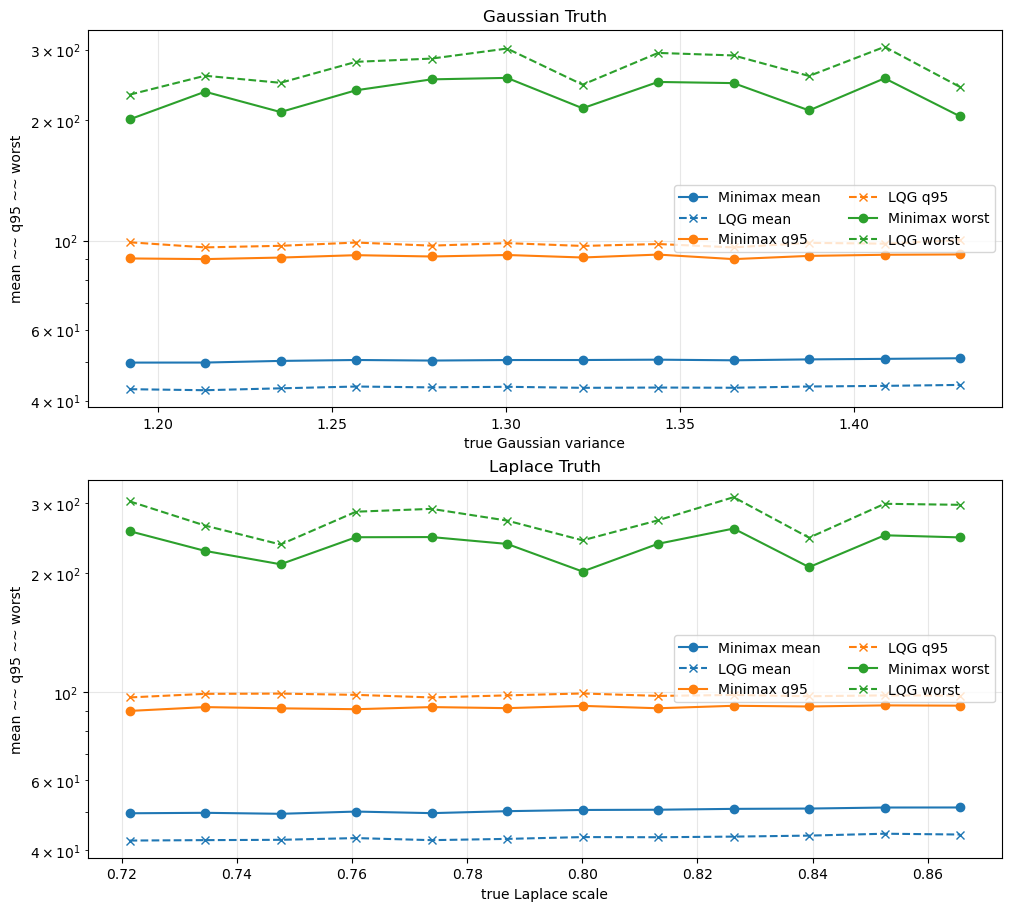

In [7]:
# 2x1 subplot: top = Gaussian, bottom = Laplace; each panel overlays mean/q95/worst for both controllers.
plot_all_metrics_two_by_one(
    gauss_mm=gaussian_minimax,
    gauss_lqg=gaussian_lqg,
    lap_mm=laplace_minimax,
    lap_lqg=laplace_lqg,
)


,delta,epsilon,mechanism,mean_cost
0,0.01,0.6931,Gaussian,77.5116
1,0.01,0.6931,Laplace,53.2052
2,0.01,0.6962,Gaussian,77.0403
3,0.01,0.6962,Laplace,53.1031
4,0.01,0.6993,Gaussian,76.5850


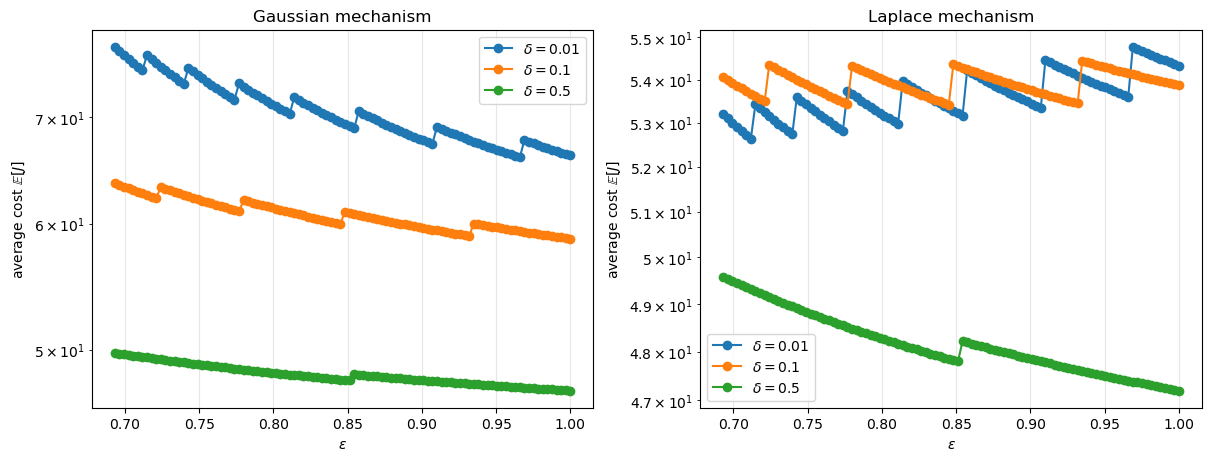

In [8]:
# Privacy-parameter sweep for the proposed minimax controller.
# For each (epsilon, delta), we build the minimax controller and evaluate
# the average cost under a Gaussian mechanism and a Laplace mechanism.
# The true mechanism parameter is taken at the DP lower bound for that family.

DELTA_SWEEP = [0.01, 0.1, 0.5]
EPSILON_SWEEP = np.linspace(math.log(2), 1.0, 100)
N_MC_PRIVACY_SWEEP = 10000

rows = []

for delta_val in DELTA_SWEEP:
    for epsilon_val in EPSILON_SWEEP:
        sigma2_lb_sweep, b_lb_sweep = privacy_lower_bounds_vector(
            C=SYSTEM["C"],
            epsilon=float(epsilon_val),
            delta=float(delta_val),
            gamma=PRIVACY["gamma"],
        )

        sigma2_ub_sweep = PRIVACY["rho_sigma"] * sigma2_lb_sweep
        b_ub_sweep = PRIVACY["rho_b"] * b_lb_sweep

        eta_sweep, _, _ = kl_radius_vector(
            sigma2_nom=sigma2_lb_sweep,
            sigma2_ub=sigma2_ub_sweep,
            b_lb=b_lb_sweep,
            b_ub=b_ub_sweep,
            L=SIM["N"] + 1,
        )

        tau_solution_sweep, _ = synthesize_minimax_closed_form_vector(
            A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
            Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
            Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
            sigma2_nom=sigma2_lb_sweep, N=SIM["N"], eta=eta_sweep,
            tau_grid=TAU_GRID_CLOSED_FORM,
        )

        if tau_solution_sweep is None:
            rows.append({
                "delta": float(delta_val),
                "epsilon": float(epsilon_val),
                "mechanism": "Gaussian",
                "mean_cost": np.nan,
            })
            rows.append({
                "delta": float(delta_val),
                "epsilon": float(epsilon_val),
                "mechanism": "Laplace",
                "mean_cost": np.nan,
            })
            continue

        minimax_ctrl_sweep = tau_solution_sweep["controller"]

        gaussian_costs = simulate_controller_vector_vectorized(
            controller=minimax_ctrl_sweep,
            A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
            Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
            Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
            noise_family="gaussian", noise_param=sigma2_lb_sweep,
            N=SIM["N"], n_mc=N_MC_PRIVACY_SWEEP, seed=SIM["seed_gaussian"],
        )
        rows.append({
            "delta": float(delta_val),
            "epsilon": float(epsilon_val),
            "mechanism": "Gaussian",
            "mean_cost": float(np.mean(gaussian_costs)),
        })

        laplace_costs = simulate_controller_vector_vectorized(
            controller=minimax_ctrl_sweep,
            A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
            Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
            Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
            noise_family="laplace", noise_param=b_lb_sweep,
            N=SIM["N"], n_mc=N_MC_PRIVACY_SWEEP, seed=SIM["seed_laplace"],
        )
        rows.append({
            "delta": float(delta_val),
            "epsilon": float(epsilon_val),
            "mechanism": "Laplace",
            "mean_cost": float(np.mean(laplace_costs)),
        })

privacy_sweep_df = pd.DataFrame(rows)
display(privacy_sweep_df.head())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
mechanisms = ["Gaussian", "Laplace"]
colors = ["C0", "C1", "C2"]

for ax, mechanism in zip(axes, mechanisms):
    df_mech = privacy_sweep_df[privacy_sweep_df["mechanism"] == mechanism]
    for color, delta_val in zip(colors, DELTA_SWEEP):
        df_line = df_mech[df_mech["delta"] == float(delta_val)].sort_values("epsilon")
        ax.plot(
            df_line["epsilon"],
            df_line["mean_cost"],
            marker="o",
            color=color,
            label=fr"$\delta = {delta_val}$",
        )

    ax.set_title(f"{mechanism} mechanism")
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"average cost $\mathbb{E}[J]$")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()
tikzplotlib.save("privacy.tex")
plt.show()


